# Patch-level DINOv2 prototypes + CLIP global semantic fusion.

Motivation
----------
Global [CLS]-token comparisons (what the shared notebook does for both CLIP and
DINOv2) throw away spatial information. For defect / anomaly-style tasks, what
usually matters is "is there some *local* patch that looks unlike anything in
the reference set?" — a question global embeddings answer poorly, because a
small localized defect gets averaged away in a single pooled vector.

This script:
  1. Extracts DINOv2 **patch tokens** (not just [CLS]) for the few-shot support
     set and the query/test set.
  2. Builds a per-class (or single "normal") **patch memory bank**, optionally
     compressed via k-means so it doesn't grow unbounded with more shots.
  3. Scores each query image by nearest-neighbor similarity of its patches to
     the memory bank (top-k mean pooling -> one score per class per image, or
     a single anomaly score against a "normal" bank).
  4. Fuses that local DINOv2 score with a global CLIP decision (reusing the
     zero-shot / cache-classifier machinery from the shared notebook) via a
     simple weighted combination.

Two usage modes are supported:
  - CLASSIFICATION mode: multiple classes, prototypes built per class, patch
    voting picks the class whose prototypes best match the query's patches.
  - ANOMALY mode: a single "normal" memory bank; the score is "distance to
    nearest normal patch", which doubles as a defect localization heatmap.

Assumes the following already exist in scope from the shared notebook:
    clip_model, clip_processor, dino_model, dino_processor, DEVICE,
    NUM_CLASSES, CIFAR10_CLASSES, train_subset, test_subset,
    train_clip, train_dino, train_labels, test_clip, test_dino, test_labels,
    clip_zeroshot_weights, tip_adapter_predict
"""



In [9]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    from sklearn.cluster import KMeans
    _HAS_SKLEARN = True
except ImportError:
    _HAS_SKLEARN = False
    print("sklearn not found — prototype compression will fall back to random subsampling.")

In [10]:
# ---------------------------------------------------------------------------
# 0. Labels + CLS-level feature extraction (with the embedding-unwrap fix)
# ---------------------------------------------------------------------------

train_labels = torch.tensor([label for _, label in train_subset])
test_labels = torch.tensor([label for _, label in test_subset])


def _unwrap_embeds(out):
    """
    Some `transformers` versions return a raw tensor from get_image_features()/
    get_text_features(); others return a ModelOutput-like wrapper (this is what
    caused the 'BaseModelOutputWithPooling has no attribute norm' error). This
    normalizes either case to a plain tensor before any F.normalize() call.
    """
    if torch.is_tensor(out):
        return out
    candidate = getattr(out, "image_embeds", None)
    if candidate is None:
        candidate = getattr(out, "text_embeds", None)
    if candidate is None:
        candidate = getattr(out, "pooler_output", None)
    if candidate is None:
        candidate = out[0]
    return candidate


@torch.no_grad()
def extract_clip_features(dataset, batch_size=64):
    feats, labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = clip_processor(images=imgs, return_tensors="pt").to(DEVICE)
        emb = clip_model.get_image_features(**inputs)
        emb = _unwrap_embeds(emb)          # <-- the fix
        emb = F.normalize(emb, dim=-1)
        feats.append(emb.cpu())
        labels.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labels)


@torch.no_grad()
def extract_dino_features(dataset, batch_size=64):
    feats, labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = dino_processor(images=imgs, return_tensors="pt").to(DEVICE)
        out = dino_model(**inputs)
        cls_emb = out.last_hidden_state[:, 0, :]      # already a plain tensor
        cls_emb = F.normalize(cls_emb, dim=-1)
        feats.append(cls_emb.cpu())
        labels.extend(labs)
    return torch.cat(feats, dim=0), torch.tensor(labels)


print("Extracting CLIP CLS features...")
train_clip, train_labels_c = extract_clip_features(train_subset)
test_clip, test_labels_c = extract_clip_features(test_subset)

print("Extracting DINOv2 CLS features...")
train_dino, train_labels_d = extract_dino_features(train_subset)
test_dino, test_labels_d = extract_dino_features(test_subset)

assert torch.equal(train_labels, train_labels_c)
assert torch.equal(train_labels, train_labels_d)
assert torch.equal(test_labels, test_labels_c)
assert torch.equal(test_labels, test_labels_d)



Extracting CLIP CLS features...
Extracting DINOv2 CLS features...


In [11]:

# ---------------------------------------------------------------------------
# 0b. CLIP zero-shot text weights + Tip-Adapter (needed for the global term)
# ---------------------------------------------------------------------------

@torch.no_grad()
def build_clip_zeroshot_weights(class_names, template="a photo of a {}."):
    prompts = [template.format(c) for c in class_names]
    inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
    text_feats = clip_model.get_text_features(**inputs)
    text_feats = _unwrap_embeds(text_feats)     # same fix applies to the text tower
    text_feats = F.normalize(text_feats, dim=-1)
    return text_feats  # [num_classes, CLIP_DIM]


clip_zeroshot_weights = build_clip_zeroshot_weights(CIFAR10_CLASSES)


def tip_adapter_predict(train_feats, train_labels_, test_feats, zeroshot_weights,
                         beta=5.5, alpha=1.0, logit_scale=100.0):
    cache_keys = train_feats.to(DEVICE)
    cache_values = F.one_hot(train_labels_.to(DEVICE), NUM_CLASSES).float()
    test_feats = test_feats.to(DEVICE)

    zeroshot_logits = logit_scale * test_feats @ zeroshot_weights.T
    affinity = test_feats @ cache_keys.T
    cache_logits = ((-1) * (beta - beta * affinity)).exp() @ cache_values

    return zeroshot_logits + alpha * cache_logits



In [12]:
# ---------------------------------------------------------------------------
# 1. Patch-level feature extraction (DINOv2)
# ---------------------------------------------------------------------------

@torch.no_grad()
def extract_dino_patch_features(dataset, batch_size=32):
    """
    Returns:
        patch_feats: [N, num_patches, dino_dim]  (L2-normalized per patch)
        labels:      [N]
    """
    all_feats, all_labels = [], []
    for start in range(0, len(dataset), batch_size):
        batch = [dataset[i] for i in range(start, min(start + batch_size, len(dataset)))]
        imgs = [im for im, _ in batch]
        labs = [lb for _, lb in batch]
        inputs = dino_processor(images=imgs, return_tensors="pt").to(DEVICE)
        out = dino_model(**inputs)
        patches = out.last_hidden_state[:, 1:, :]      # drop [CLS] token -> [B, num_patches, dim]
        patches = F.normalize(patches, dim=-1)
        all_feats.append(patches.cpu())
        all_labels.extend(labs)
    return torch.cat(all_feats, dim=0), torch.tensor(all_labels)



In [13]:
# ---------------------------------------------------------------------------
# 2. Patch memory bank (per-class or single "normal" bank)
# ---------------------------------------------------------------------------

class PatchPrototypeBank:
    """
    Stores a compressed set of representative patch embeddings per class
    (or a single bank for anomaly-detection mode).
    """

    def __init__(self, feature_dim, max_prototypes_per_class=256, seed=0):
        self.feature_dim = feature_dim
        self.max_prototypes_per_class = max_prototypes_per_class
        self.seed = seed
        self.banks = {}   # class_id (or "normal") -> [num_prototypes, dim] tensor

    def _compress(self, patches_2d):
        """patches_2d: [num_patches_total, dim] -> [<=max_prototypes, dim]"""
        n = patches_2d.shape[0]
        cap = self.max_prototypes_per_class
        if n <= cap:
            return patches_2d
        if _HAS_SKLEARN:
            km = KMeans(n_clusters=cap, n_init=4, random_state=self.seed)
            km.fit(patches_2d.numpy())
            centers = torch.tensor(km.cluster_centers_, dtype=patches_2d.dtype)
            return F.normalize(centers, dim=-1)
        else:
            rng = np.random.RandomState(self.seed)
            idx = rng.choice(n, size=cap, replace=False)
            return patches_2d[idx]

    def fit(self, patch_feats, labels):
        """
        patch_feats: [N, num_patches, dim]
        labels:      [N]  (per-image class id)
        Builds one compressed prototype set per class.
        """
        labels = labels.numpy()
        for c in sorted(set(labels.tolist())):
            mask = labels == c
            class_patches = patch_feats[mask].reshape(-1, self.feature_dim)  # flatten images*patches
            self.banks[c] = self._compress(class_patches)
            print(f"  class {c}: {class_patches.shape[0]} raw patches -> "
                  f"{self.banks[c].shape[0]} prototypes")

    def fit_single_bank(self, patch_feats, key="normal"):
        """For anomaly-detection mode: one bank built from reference/normal images only."""
        flat = patch_feats.reshape(-1, self.feature_dim)
        self.banks[key] = self._compress(flat)
        print(f"  '{key}' bank: {flat.shape[0]} raw patches -> {self.banks[key].shape[0]} prototypes")

    def score_classification(self, query_patch_feats, top_k=10):
        """
        query_patch_feats: [N, num_patches, dim]
        Returns: [N, num_classes] similarity scores (higher = more supportive of that class)
        Each image's score for class c = mean of its top_k patch similarities to class c's bank.
        """
        classes = sorted(self.banks.keys())
        N, P, D = query_patch_feats.shape
        scores = torch.zeros(N, len(classes))
        flat_query = query_patch_feats.reshape(N * P, D).to(DEVICE)
        for ci, c in enumerate(classes):
            bank = self.banks[c].to(DEVICE)                       # [K, D]
            sims = flat_query @ bank.T                             # [N*P, K]
            best_per_patch = sims.max(dim=-1).values                # [N*P] best match per patch
            best_per_patch = best_per_patch.reshape(N, P)
            topk_vals, _ = best_per_patch.topk(min(top_k, P), dim=-1)
            scores[:, ci] = topk_vals.mean(dim=-1).cpu()
        return scores, classes

    def anomaly_score(self, query_patch_feats, key="normal", top_k=10):
        """
        query_patch_feats: [N, num_patches, dim]
        Returns:
            image_scores: [N]           higher = more anomalous
            patch_maps:   [N, P]         per-patch anomaly score (1 - similarity to nearest normal patch)
        """
        bank = self.banks[key].to(DEVICE)
        N, P, D = query_patch_feats.shape
        flat_query = query_patch_feats.reshape(N * P, D).to(DEVICE)
        sims = flat_query @ bank.T                     # [N*P, K]
        best_sim = sims.max(dim=-1).values.reshape(N, P)   # nearest-neighbor similarity per patch
        patch_anomaly = 1.0 - best_sim                     # higher = more anomalous
        topk_vals, _ = patch_anomaly.topk(min(top_k, P), dim=-1)
        image_scores = topk_vals.mean(dim=-1)
        return image_scores.cpu(), patch_anomaly.cpu()



In [14]:
# ---------------------------------------------------------------------------
# 3. Fusion with CLIP's global decision
# ---------------------------------------------------------------------------

def fuse_global_and_patch_scores(clip_global_logits, dino_patch_scores, alpha=0.5):
    """
    clip_global_logits:  [N, C]  raw logits/scores from CLIP (e.g. zero-shot or Tip-Adapter)
    dino_patch_scores:   [N, C]  patch-based scores from PatchPrototypeBank.score_classification
    alpha: weight on the CLIP (global/semantic) term; (1 - alpha) goes to DINOv2 (local/patch) term.
    Both score tensors are min-max normalized per-column before combining so their
    (very different) scales don't let one term dominate by default.
    """
    def _norm(x):
        x_min = x.min(dim=0, keepdim=True).values
        x_max = x.max(dim=0, keepdim=True).values
        return (x - x_min) / (x_max - x_min + 1e-8)

    clip_n = _norm(clip_global_logits)
    dino_n = _norm(dino_patch_scores)
    fused = alpha * clip_n + (1 - alpha) * dino_n
    return fused



In [15]:
# ---------------------------------------------------------------------------
# 4. End-to-end classification demo (CIFAR-10, multi-class mode)
# ---------------------------------------------------------------------------

def run_classification_demo(alpha=0.5, max_prototypes_per_class=256, top_k=10):
    print("Extracting DINOv2 patch features for support set...")
    train_patches, train_patch_labels = extract_dino_patch_features(train_subset)
    print("Extracting DINOv2 patch features for evaluation set...")
    test_patches, test_patch_labels = extract_dino_patch_features(test_subset)
    assert torch.equal(train_patch_labels, train_labels)
    assert torch.equal(test_patch_labels, test_labels)

    dino_dim = train_patches.shape[-1]
    bank = PatchPrototypeBank(feature_dim=dino_dim, max_prototypes_per_class=max_prototypes_per_class)
    print("Building per-class patch prototype banks...")
    bank.fit(train_patches, train_labels)

    print("Scoring evaluation set against patch prototypes...")
    dino_scores, class_order = bank.score_classification(test_patches, top_k=top_k)

    clip_logits = tip_adapter_predict(train_clip, train_labels, test_clip, clip_zeroshot_weights,
                                       beta=5.5, alpha=1.0).cpu()

    fused = fuse_global_and_patch_scores(clip_logits, dino_scores, alpha=alpha)

    preds_clip_only = clip_logits.argmax(-1)
    preds_dino_only = dino_scores.argmax(-1)
    preds_fused = fused.argmax(-1)

    acc = lambda preds: (preds == test_labels).float().mean().item()
    print(f"\nCLIP global only (Tip-Adapter):        {acc(preds_clip_only)*100:.2f}%")
    print(f"DINOv2 patch-prototype only:            {acc(preds_dino_only)*100:.2f}%")
    print(f"Fused (alpha={alpha}):                        {acc(preds_fused)*100:.2f}%")

    return {"clip_only": acc(preds_clip_only), "dino_only": acc(preds_dino_only), "fused": acc(preds_fused)}


def alpha_sweep_demo(alphas=(0.0, 0.25, 0.5, 0.75, 1.0)):
    """Sweep the CLIP/DINOv2 fusion weight and plot accuracy — cheap since it reuses cached scores."""
    print("Extracting features once, then sweeping fusion weight alpha...")
    train_patches, _ = extract_dino_patch_features(train_subset)
    test_patches, _ = extract_dino_patch_features(test_subset)

    dino_dim = train_patches.shape[-1]
    bank = PatchPrototypeBank(feature_dim=dino_dim, max_prototypes_per_class=256)
    bank.fit(train_patches, train_labels)
    dino_scores, _ = bank.score_classification(test_patches, top_k=10)

    clip_logits = tip_adapter_predict(train_clip, train_labels, test_clip, clip_zeroshot_weights,
                                       beta=5.5, alpha=1.0).cpu()

    accs = []
    for a in alphas:
        fused = fuse_global_and_patch_scores(clip_logits, dino_scores, alpha=a)
        acc = (fused.argmax(-1) == test_labels).float().mean().item()
        accs.append(acc)
        print(f"  alpha={a:.2f} -> {acc*100:.2f}%")

    plt.figure(figsize=(6, 4))
    plt.plot(alphas, [a * 100 for a in accs], marker="o")
    plt.xlabel("alpha (weight on CLIP global term)")
    plt.ylabel("Test accuracy (%)")
    plt.title("CLIP-global vs DINOv2-patch fusion weight sweep")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return accs



=== Classification mode (patch prototypes + CLIP global fusion) ===
Extracting DINOv2 patch features for support set...
Extracting DINOv2 patch features for evaluation set...
Building per-class patch prototype banks...
  class 0: 4096 raw patches -> 256 prototypes
  class 1: 4096 raw patches -> 256 prototypes
  class 2: 4096 raw patches -> 256 prototypes
  class 3: 4096 raw patches -> 256 prototypes
  class 4: 4096 raw patches -> 256 prototypes
  class 5: 4096 raw patches -> 256 prototypes
  class 6: 4096 raw patches -> 256 prototypes
  class 7: 4096 raw patches -> 256 prototypes
  class 8: 4096 raw patches -> 256 prototypes
  class 9: 4096 raw patches -> 256 prototypes
Scoring evaluation set against patch prototypes...

CLIP global only (Tip-Adapter):        92.00%
DINOv2 patch-prototype only:            87.70%
Fused (alpha=0.5):                        94.80%

=== Fusion weight sweep ===
Extracting features once, then sweeping fusion weight alpha...
  class 0: 4096 raw patches -> 256 

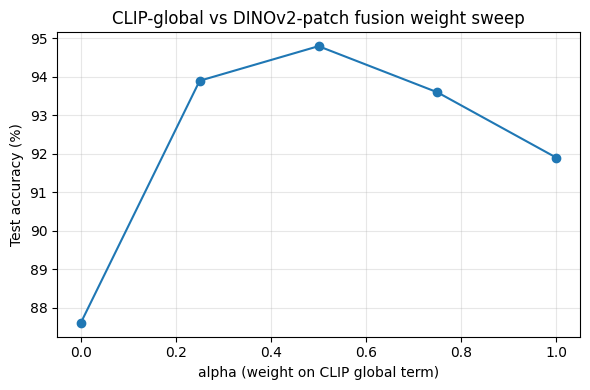


=== Anomaly-detection mode (single 'normal' bank + heatmap) ===
Extracting DINOv2 patches for 16 'normal' reference images...
  'normal' bank: 4096 raw patches -> 512 prototypes
Extracting DINOv2 patches for query set...

Mean anomaly score for true 'normal' images:    0.6288
Mean anomaly score for true 'anomalous' images: 0.8229
(Anomalous mean should be clearly higher than normal mean if patch prototypes are useful.)


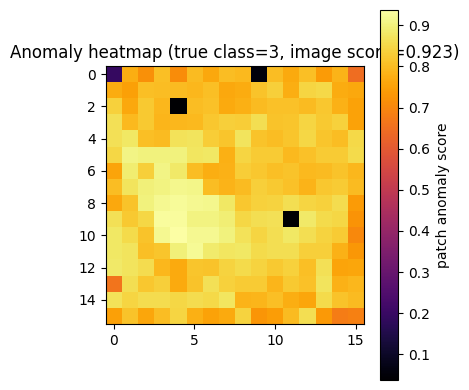

In [16]:
# ---------------------------------------------------------------------------
# 5. Anomaly-detection mode demo (single "normal" class + heatmap)
#    Use this variant directly for defect/anomaly-style tasks: fit the bank
#    on reference/normal images only, then score any query image's deviation.
# ---------------------------------------------------------------------------

def run_anomaly_demo(normal_class_id=0, num_normal_shots=16, num_query_per_class=20, top_k=10):
    """
    Treats one CIFAR-10 class as the 'normal' reference class and every other
    class as an out-of-distribution / 'anomalous' query, purely to demonstrate
    the mechanics — swap in your own normal/defect image folders for real use.
    """
    from torch.utils.data import Subset

    all_labels_train = np.array([lb for _, lb in train_raw])
    normal_idx = np.where(all_labels_train == normal_class_id)[0][:num_normal_shots]
    normal_subset = Subset(train_raw, normal_idx.tolist())

    print(f"Extracting DINOv2 patches for {num_normal_shots} 'normal' reference images...")
    normal_patches, _ = extract_dino_patch_features(normal_subset)

    dino_dim = normal_patches.shape[-1]
    bank = PatchPrototypeBank(feature_dim=dino_dim, max_prototypes_per_class=512)
    bank.fit_single_bank(normal_patches, key="normal")

    # Build a small mixed query set: some normal-class images, some other classes
    query_idx = []
    all_labels_test = np.array([lb for _, lb in test_raw])
    for c in range(NUM_CLASSES):
        idxs = np.where(all_labels_test == c)[0][:num_query_per_class]
        query_idx.extend(idxs.tolist())
    query_subset = Subset(test_raw, query_idx)
    query_labels = torch.tensor([test_raw[i][1] for i in query_idx])

    print("Extracting DINOv2 patches for query set...")
    query_patches, _ = extract_dino_patch_features(query_subset)

    image_scores, patch_maps = bank.anomaly_score(query_patches, key="normal", top_k=top_k)

    is_anomalous_true = (query_labels != normal_class_id).float()
    normal_mean = image_scores[is_anomalous_true == 0].mean().item()
    anomalous_mean = image_scores[is_anomalous_true == 1].mean().item()
    print(f"\nMean anomaly score for true 'normal' images:    {normal_mean:.4f}")
    print(f"Mean anomaly score for true 'anomalous' images: {anomalous_mean:.4f}")
    print("(Anomalous mean should be clearly higher than normal mean if patch prototypes are useful.)")

    side = int(math.sqrt(patch_maps.shape[1]))
    example_idx = int(torch.argmax(image_scores * is_anomalous_true))
    heatmap = patch_maps[example_idx].reshape(side, side).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(heatmap, cmap="inferno")
    plt.colorbar(label="patch anomaly score")
    plt.title(f"Anomaly heatmap (true class={query_labels[example_idx].item()}, "
              f"image score={image_scores[example_idx]:.3f})")
    plt.tight_layout()
    plt.show()

    return image_scores, patch_maps, query_labels


if __name__ == "__main__":
    print("=== Classification mode (patch prototypes + CLIP global fusion) ===")
    run_classification_demo(alpha=0.5)

    print("\n=== Fusion weight sweep ===")
    alpha_sweep_demo()

    print("\n=== Anomaly-detection mode (single 'normal' bank + heatmap) ===")
    run_anomaly_demo(normal_class_id=0)